<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/11.11_Outlier_and_Novelty_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 11 - Deteksi Pencilan dan Kebaruan (Outlier and Novelty Detection)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 11 Outlier and Novelty Detection** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

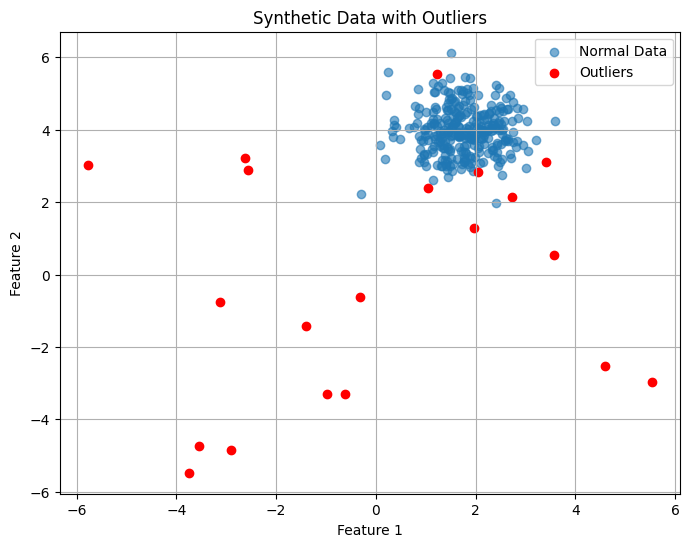

In [1]:
# Muat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Hasilkan kumpulan data sintetis dengan outlier yang disengaja
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.60, random_state=2024)
np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_with_outliers = np.vstack([X, outliers])

# Visualisasikan data dengan outlier
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], label="Normal Data", alpha=0.6)
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label="Outliers")
plt.title("Synthetic Data with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Bagaimana cara melakukannya...
Untuk mendemonstrasikan teknik deteksi outlier dan kebaruan, kami akan menggunakan `LocalOutlierFactor()` (atau LOF) dari `sklearn.neighbours`. Ini adalah metode tanpa pengawasan yang mendeteksi anomali dengan membandingkan kepadatan titik data lokal.

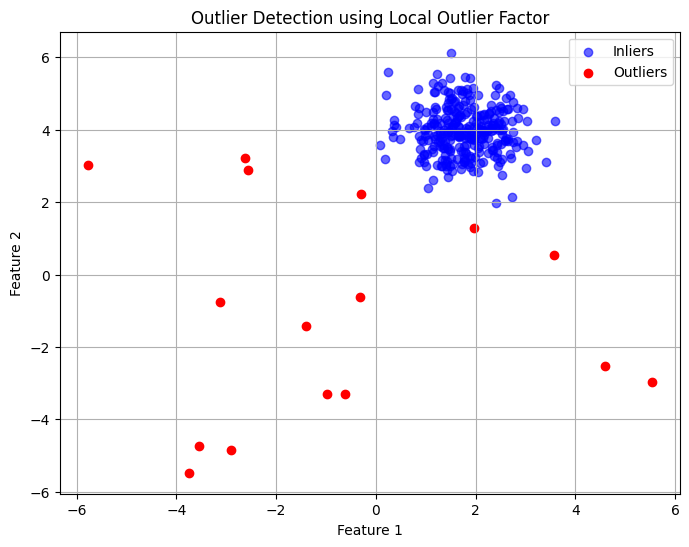

In [2]:
# Muat modelnya
from sklearn.neighbors import LocalOutlierFactor

# Sesuaikan model dan prediksi outlier
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_with_outliers)

# Plot prediksinya
plt.figure(figsize=(8, 6))
plt.scatter(X_with_outliers[y_pred == 1, 0], X_with_outliers[y_pred == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_with_outliers[y_pred == -1, 0], X_with_outliers[y_pred == -1, 1],
            color='red', label='Outliers')
plt.title("Outlier Detection using Local Outlier Factor")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Cara kerjanya...
Metode deteksi outlier dan kebaruan memperkirakan apakah setiap titik data sampel menyimpang secara signifikan dari distribusi data yang diharapkan.

## Pengertian Hutan Isolasi
Isolation Forest adalah algoritma yang efisien dan terukur untuk mendeteksi outlier dalam kumpulan data berdimensi tinggi. Daripada membuat profil titik data normal dan mengidentifikasi penyimpangan, ini bekerja dengan mengisolasi anomali. Pencilan (Outlier) lebih mudah diisolasi karena cenderung berbeda secara signifikan dari sebagian besar data. Algoritme secara acak memilih fitur dan membagi data berdasarkan ambang batas acak; lebih sedikit pemisahan biasanya diperlukan untuk mengisolasi anomali.
Metode ini sangat cocok untuk kumpulan data besar dan mampu mendeteksi outlier dan hal baru, menjadikannya alat serbaguna dalam perangkat pembelajaran mesin.

## Bersiap
Kami akan membuat kumpulan data sintetis yang menyertakan outlier yang terlihat. Hal ini memungkinkan kita membandingkan kinerja Hutan Isolasi dengan distribusi yang diketahui.

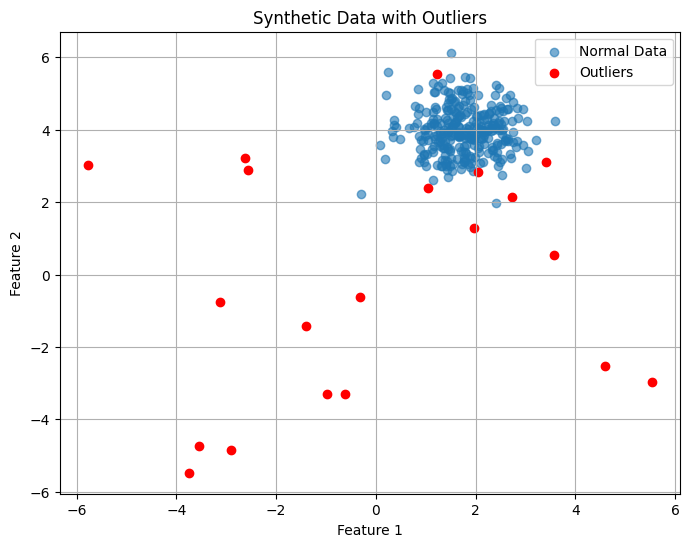

In [3]:
# Muat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

# Hasilkan data sintetis dengan outlier
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.6, random_state=2024)
np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_combined = np.vstack([X, outliers])

# Visualisasikan datanya
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], label="Normal Data", alpha=0.6)
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label="Outliers")
plt.title("Synthetic Data with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Bagaimana cara melakukannya...
Kami akan menggunakan `IsolationForest()` dari `sklearn.ensemble` untuk mengidentifikasi anomali dalam kumpulan data.

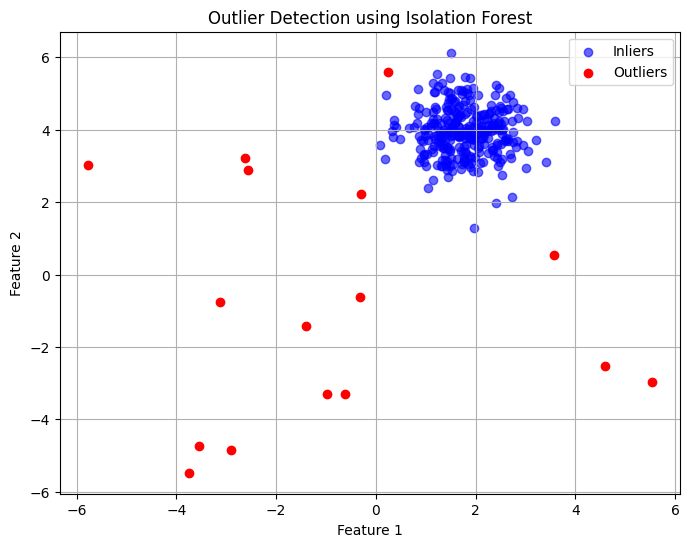

In [4]:
# Muat dan konfigurasikan model
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=2024)

# Sesuaikan model dan buat prediksi
model.fit(X_combined)
y_pred = model.predict(X_combined)

# Gambarkan hasilnya
plt.figure(figsize=(8, 6))
plt.scatter(X_combined[y_pred == 1, 0], X_combined[y_pred == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_combined[y_pred == -1, 0], X_combined[y_pred == -1, 1],
            color='red', label='Outliers')
plt.title("Outlier Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Cara kerjanya...
Hutan Isolasi mengisolasi anomali alih-alih membuat profil pengamatan normal. Algoritmanya bekerja sebagai berikut:
- Pemisahan Acak: Pada setiap node, algoritme secara acak memilih fitur dan nilai pemisahan. Hal ini berlanjut secara rekursif, membangun pohon dimana anomali cenderung dapat diisolasi dengan lebih cepat.
- Panjang Jalur: Skor anomali setiap titik didasarkan pada rata-rata panjang jalur di semua pohon. Jalur yang lebih pendek menyiratkan kemungkinan lebih tinggi untuk menjadi outlier.
- Kontaminasi: Parameter kontaminasi menentukan proporsi outlier yang diharapkan dalam kumpulan data dan menetapkan ambang batas untuk klasifikasi.
Karena Isolation Forest tidak bergantung pada metrik jarak atau kepadatan, ia bekerja dengan baik pada kumpulan data berdimensi tinggi dan melakukan penskalaan secara efisien dengan sampel besar.

## SVM Satu Kelas untuk Deteksi Kebaruan
Mesin Vektor Dukungan Satu Kelas (SVM Satu Kelas) adalah teknik umum untuk mendeteksi hal baru, terutama ketika kita hanya memiliki akses ke data "normal" selama pelatihan. Tidak seperti metode deteksi outlier lainnya, SVM Satu Kelas mencoba mempelajari batas normalitas dan mengklasifikasikan titik mana pun yang berada di luar batas tersebut sebagai hal baru. Hal ini membuatnya cocok untuk kasus penggunaan seperti deteksi penipuan, prediksi kegagalan peralatan, atau diagnostik penyakit langka—situasi apa pun ketika contoh anomali sangat jarang atau tidak tersedia selama pelatihan.
SVM Satu Kelas adalah metode berbasis kernel yang dapat memodelkan batas nonlinier, memberikan fleksibilitas yang signifikan ketika memisahkan instance normal dari anomali yang tidak terlihat.

## Bersiap
Kami akan membuat kumpulan data dengan data latih normal dan menyertakan anomali hanya pada waktu pengujian untuk mendemonstrasikan deteksi hal baru.

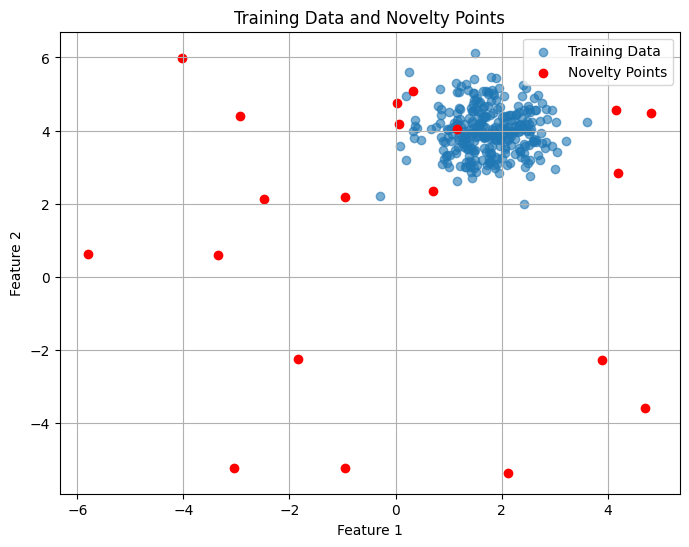

In [5]:
# Muat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Menghasilkan data latih (hanya normal)
X_train, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.6, random_state=2024)

# Hasilkan data uji (normal + kebaruan)
X_test_normal, _ = make_blobs(n_samples=100, centers=1, cluster_std=0.6, center_box=(0, 1), random_state=42)
X_test_novelty = np.random.uniform(low=-6, high=6, size=(20, 2))
X_test = np.vstack([X_test_normal, X_test_novelty])

# Visualisasikan datanya
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], label='Training Data', alpha=0.6)
plt.scatter(X_test_novelty[:, 0], X_test_novelty[:, 1], color='red', label='Novelty Points')
plt.title("Training Data and Novelty Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Bagaimana cara melakukannya...
Sekarang kita akan menggunakan `OneClassSVM()` dari `sklearn.svm` untuk membuat detektor baru.

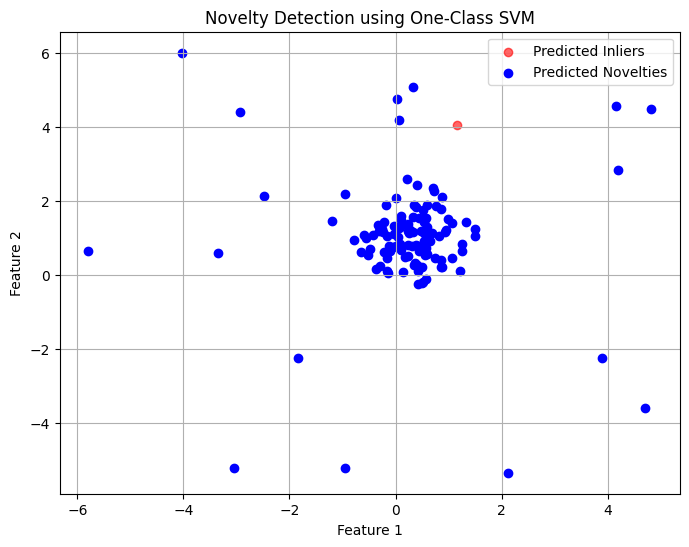

In [6]:
# Buat instance dan sesuaikan modelnya
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model.fit(X_train)

# Buatlah prediksi pada data uji
y_pred = model.predict(X_test)

# Plot prediksinya
plt.figure(figsize=(8, 6))
plt.scatter(X_test[y_pred == 1, 0], X_test[y_pred == 1, 1], color='red', label='Predicted Inliers', alpha=0.6)
plt.scatter(X_test[y_pred == -1, 0], X_test[y_pred == -1, 1], color='blue', label='Predicted Novelties')
plt.title("Novelty Detection using One-Class SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Cara kerjanya...
SVM Kelas Satu memisahkan data normal dari data asal dalam ruang fitur yang diubah menggunakan fungsi keputusan. Parameter utama meliputi:
- Kernel: SVM Satu Kelas dapat menggunakan kernel linier, polinomial, atau RBF. RBF paling umum digunakan karena dapat memodelkan batas non-linier.
- Gamma: Mendefinisikan pengaruh satu contoh pelatihan. Nilai rendah berarti jangkauan ‘jauh’, nilai tinggi berarti jangkauan ‘dekat’.
-Nu: Batas atas pada pecahan kesalahan pelatihan dan batas bawah pada pecahan support vector. Ini mengontrol trade-off antara kesalahan positif dan fleksibilitas model.
Tidak seperti metode deteksi outlier yang melihat semua data (pelatihan + pengujian), SVM Satu Kelas belajar dari data normal saja dan dievaluasi hanya pada titik baru yang tidak terlihat.

## Faktor Pencilan (Outlier) Lokal (LOF)
Local Outlier Factor (LOF) adalah metode deteksi anomali berbasis kepadatan yang mengidentifikasi outlier dengan membandingkan kepadatan lokal setiap titik data dengan kepadatan lokal di titik tetangganya. Daripada menggunakan ambang batas global, LOF menilai seberapa terisolasi suatu titik data dibandingkan dengan lingkungan sekitarnya. Jika suatu titik terletak di wilayah yang kepadatannya jauh lebih rendah dibandingkan titik tetangganya, maka titik tersebut ditandai sebagai outlier.
LOF sangat efektif dalam kumpulan data yang kepadatan titik datanya bervariasi di seluruh ruang fitur. Hal ini dapat mendeteksi anomali lokal yang mungkin diabaikan oleh metode global seperti Isolation Forest.

## Bersiap
Kami akan membuat kumpulan data yang berisi cluster dengan kepadatan berbeda dan menambahkan noise untuk mensimulasikan outlier.

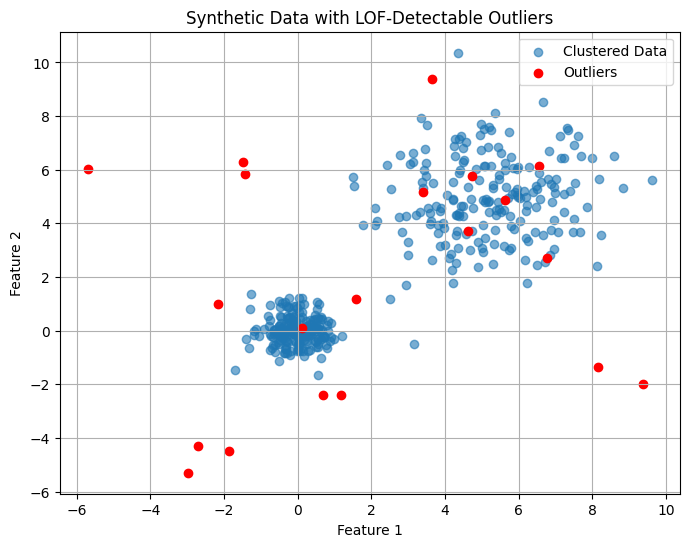

In [7]:
# Muat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import LocalOutlierFactor

# Buat data sintetis dengan cluster dan noise
X, _ = make_blobs(n_samples=400, centers=[[0, 0], [5, 5]], cluster_std=[0.5, 1.5], random_state=2024)
np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=10, size=(20, 2))
X_with_outliers = np.vstack([X, outliers])

# Visualisasikan datanya
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], label="Clustered Data", alpha=0.6)
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label="Outliers")
plt.title("Synthetic Data with LOF-Detectable Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Bagaimana cara melakukannya...
Kami akan menerapkan `LocalOutlierFactor()` dari `sklearn.neighbors` untuk mengidentifikasi anomali lokal.

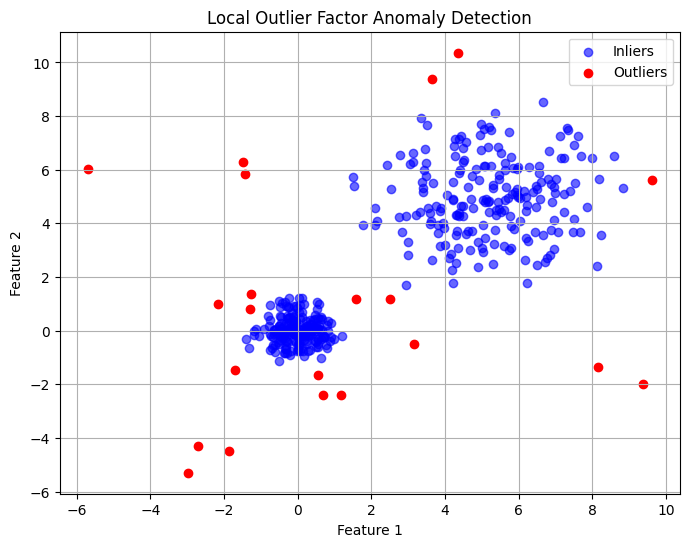

In [8]:
# Inisialisasi dan sesuaikan model
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_with_outliers)

# Plot prediksinya
plt.figure(figsize=(8, 6))
plt.scatter(X_with_outliers[y_pred == 1, 0], X_with_outliers[y_pred == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_with_outliers[y_pred == -1, 0], X_with_outliers[y_pred == -1, 1],
            color='red', label='Outliers')
plt.title("Local Outlier Factor Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Cara kerjanya...
LOF mengevaluasi tingkat kelainan suatu titik data dengan:
- Estimasi Kepadatan Lokal: Ini menghitung kepadatan lokal di sekitar titik data menggunakan jarak ke k k-Nearest Neighbors (k-NN)nya (lihat Bab 4 untuk penyegaran).
- Jarak Jangkauan: Jarak jangkauan memperhalus jarak dengan mempertimbangkan maksimum antara jarak sebenarnya dan k-jarak tetangga.
- Skor LOF: Skor LOF suatu titik adalah rasio rata-rata kepadatan lokal tetangganya terhadap kepadatan lokalnya sendiri. Nilai yang jauh lebih besar dari 1 menunjukkan “keanehan”.
Tidak seperti model lainnya, LOF tidak mengekspos metode `.predict()` untuk data yang tidak terlihat. Ini benar-benar merupakan detektor anomali tanpa pengawasan yang digunakan pada waktu pelatihan.

## Mengevaluasi Model Deteksi Pencilan (Outlier)
Mengevaluasi model deteksi outlier lebih bernuansa dibandingkan mengevaluasi model tradisional yang diawasi. Pencilan (Outlier) biasanya jarang terjadi, dan label mungkin tidak selalu tersedia, sehingga membatasi penggunaan metrik standar seperti akurasi. Sebagai gantinya, kami menggunakan metrik yang sesuai untuk kumpulan data dan keputusan biner yang tidak seimbang, seperti matriks presisi, perolehan, skor F1, ROC-AUC, dan kebingungan – yang semuanya telah kami gunakan beberapa kali hingga saat ini. Ketika label sebenarnya tersedia (seperti dalam kumpulan data sintetis), kami dapat langsung menilai bagaimana model kami mengidentifikasi titik-titik anomali.
Di bagian ini, kita akan membahas strategi evaluasi model deteksi outlier menggunakan data berlabel, membandingkan performa model, dan memvisualisasikan hasilnya agar dapat ditafsirkan.

## Bersiap
Kami akan membuat kumpulan data berlabel dengan perbedaan yang jelas antara inlier dan outlier.

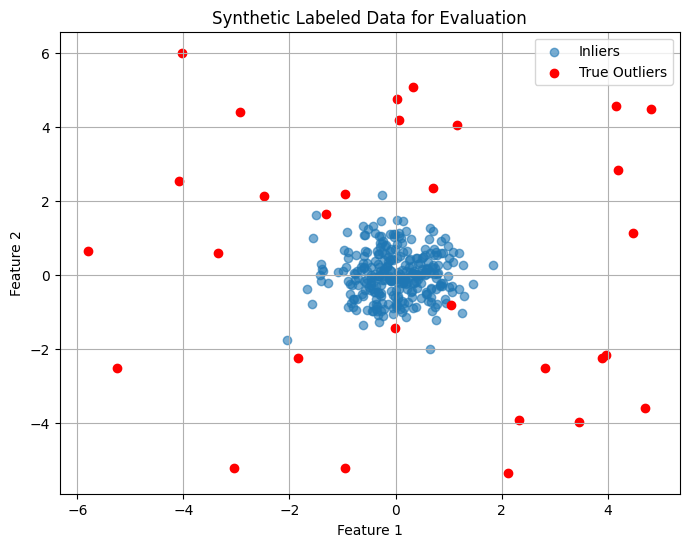

In [9]:
# Muat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Hasilkan data sintetis berlabel
X_inliers, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.6, random_state=2024)
X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_inliers, X_outliers])
y_true = np.array([0] * len(X_inliers) + [1] * len(X_outliers))  # 0 = inlier, 1 = outlier

# Visualisasikan datanya
plt.figure(figsize=(8, 6))
plt.scatter(X[y_true == 0][:, 0], X[y_true == 0][:, 1], label='Inliers', alpha=0.6)
plt.scatter(X[y_true == 1][:, 0], X[y_true == 1][:, 1], color='red', label='True Outliers')
plt.title("Synthetic Labeled Data for Evaluation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Bagaimana cara melakukannya...
Kami akan menyesuaikan model Hutan Isolasi dan mengevaluasi prediksinya menggunakan metrik klasifikasi.

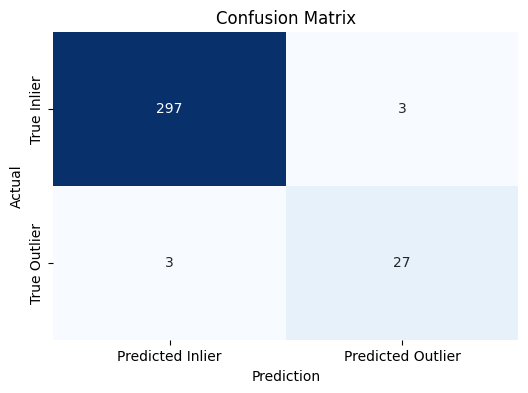

,precision,recall,f1-score,support
0,0.990,0.990,0.990,300
1,0.900,0.900,0.900,30
accuracy,0.982,0.982,0.982,1
macro avg,0.945,0.945,0.945,330
weighted avg,0.982,0.982,0.982,330


ROC-AUC Score: 0.005111111111111106


In [10]:
import pandas as pd

# Sesuaikan model dan dapatkan prediksi
model = IsolationForest(contamination=0.09, random_state=2024)
model.fit(X)
y_pred = model.predict(X)
y_pred_binary = np.where(y_pred == 1, 0, 1)  # convert to 0 = inlier, 1 = outlier

# Hasilkan dan plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Inlier', 'Predicted Outlier'],
            yticklabels=['True Inlier', 'True Outlier'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Cetak laporan klasifikasi sebagai DataFrame dan AUC yang ditata
report = classification_report(y_true, y_pred_binary, output_dict=True)
report = pd.DataFrame(report).transpose()
styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)
print("ROC-AUC Score:", roc_auc_score(y_true, model.decision_function(X)))


## Cara kerjanya...
Setiap metrik menawarkan tampilan unik tentang performa model:
- Presisi: Proporsi prediksi outlier yang sebenarnya merupakan outlier sebenarnya. Presisi tinggi menunjukkan lebih sedikit kesalahan positif.
- Recall: Proporsi outlier aktual yang teridentifikasi dengan benar. Ingatan yang tinggi berarti lebih sedikit negatif palsu.
- Skor F1: Rata-rata harmonik dari presisi dan perolehan. Sebuah ukuran yang seimbang ketika menghadapi ketidakseimbangan kelas.
- Matriks Kebingungan: Menawarkan wawasan mendetail tentang distribusi prediksi.
- Skor ROC-AUC: Mengukur kemampuan model untuk memberi peringkat outlier sebenarnya di atas inlier.
Jika label kelas tidak tersedia (hal ini umum terjadi), evaluasi model mungkin bergantung pada validasi ahli, kesalahan rekonstruksi (misalnya, untuk autoencoder), atau metrik proksi seperti stabilitas prediksi.

## Menangani Pencilan (Outlier) yang Terdeteksi
Setelah outlier teridentifikasi, kita dihadapkan pada keputusan penting: bagaimana cara menanganinya? Strategi yang tepat bergantung pada konteks masalah dan sifat data. Pencilan (Outlier) dapat bersifat informatif (misalnya, kasus penipuan) atau mengganggu (misalnya, gangguan sensor) dan pilihan cara menanganinya akan memengaruhi performa model dan kemampuan interpretasi.
Bagian ini menguraikan strategi umum untuk menangani outlier, termasuk penghapusan, transformasi, imputasi (imputation), dan mempertahankannya untuk pemodelan khusus. Kami akan membahas contoh kode praktis untuk mendemonstrasikan setiap pendekatan.

## Bersiap
Kami akan menggunakan kumpulan data yang menyertakan outlier yang terdeteksi melalui metode Hutan Isolasi.

In [11]:
# Muat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

# Hasilkan kumpulan data
X_inliers, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.6, random_state=2024)
X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_inliers, X_outliers])

# Deteksi outlier menggunakan Isolation Forest
model = IsolationForest(contamination=0.09, random_state=2024)
model.fit(X)
outlier_mask = model.predict(X) == -1

## Bagaimana cara melakukannya...
Kami sekarang akan mengeksplorasi berbagai strategi untuk menangani outlier yang terdeteksi.

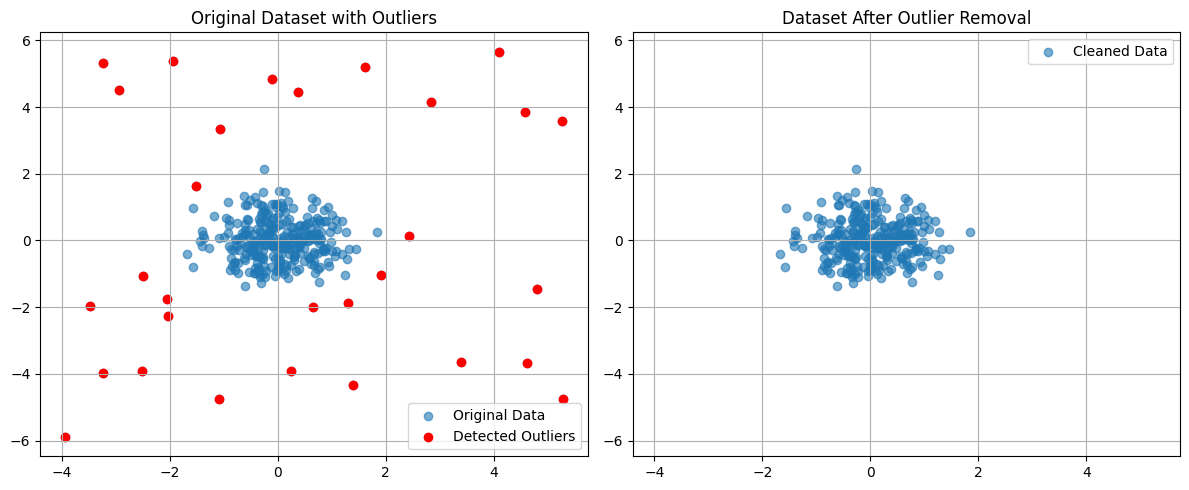

In [12]:
# Hapus outlier dari kumpulan data
X_cleaned = X[~outlier_mask]

# Ganti outlier dengan median berdasarkan fitur
X_replaced = X.copy()
median_vals = np.median(X[~outlier_mask], axis=0)
X_replaced[outlier_mask] = median_vals

# Batasi outlier ke batas yang ditentukan (winsorisasi)
X_df = pd.DataFrame(X, columns=['feature1', 'feature2'])
X_capped = X_df.copy()
for col in X_df.columns:
    lower = X_df[col].quantile(0.05)
    upper = X_df[col].quantile(0.95)
    X_capped[col] = X_df[col].clip(lower=lower, upper=upper)

# Visualisasikan kumpulan data asli dan bersih dengan sumbu yang cocok
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.scatter(X[:, 0], X[:, 1], label='Original Data', alpha=0.6)
ax1.scatter(X[outlier_mask][:, 0], X[outlier_mask][:, 1], color='red', label='Detected Outliers')
ax1.set_title('Original Dataset with Outliers')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(X_cleaned[:, 0], X_cleaned[:, 1], label='Cleaned Data', alpha=0.6)
ax2.set_title('Dataset After Outlier Removal')
ax2.legend()
ax2.grid(True)

ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())

plt.tight_layout()
plt.show()

## Cara kerjanya...
Pilihan strategi bergantung pada asumsi yang mendasari dan dampak outlier terhadap akurasi model:
- Penghapusan: Cocok jika outlier dihasilkan dari gangguan, kesalahan, atau catatan yang rusak. Namun, penghapusan yang berlebihan dapat menghilangkan sinyal yang berguna.
- Penggantian: Mengganti outlier dengan mean, median, atau statistik pusat lainnya. Hal ini mempertahankan ukuran kumpulan data tetapi dapat menimbulkan bias.
- Pembatasan (Winsorisasi): Membatasi nilai pada rentang tertentu. Berguna ketika nilai-nilai harus berada dalam batas tetapi tetap mempertahankan urutan.
- Penandaan: Pencilan (Outlier) juga dapat dipertahankan tetapi ditandai sebagai fitur baru, sehingga model dapat mempelajari perbedaan perilaku.

## Memilih Teknik Deteksi yang Tepat
Dengan berbagai pendekatan untuk deteksi outlier dan kebaruan yang tersedia di scikit-learn, memilih metode yang tepat bergantung pada sifat kumpulan data Anda, ada atau tidaknya label, dan kasus penggunaan. Di bagian ini, kami akan membandingkan karakteristik utama dari berbagai algoritme pendeteksian yang dibahas dalam bab ini dan memberikan panduan praktis untuk membantu Anda menentukan pendekatan mana yang paling sesuai dengan kebutuhan Anda.
Kami akan mengeksplorasi kriteria keputusan termasuk asumsi tentang distribusi data, skalabilitas, dimensi, interpretasi, dan apakah model mendukung prediksi pada data baru yang tidak terlihat.

## Bersiap
Kami akan merangkum penyiapan eksperimental dan menggunakan kembali hasil evaluasi model dari bagian sebelumnya. (CATATAN: Bagian ini benar-benar OPSIONAL)

In [13]:
# Muat perpustakaan
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Buat tabel perbandingan metode
data = {
    "Algorithm": ["Isolation Forest", "Local Outlier Factor", "One-Class SVM"],
    "Handles High Dimensions": ["Yes", "No", "Sometimes"],
    "Learns From Unlabeled Data": ["Yes", "Yes", "No (novelty only)"],
    "Supports New Predictions": ["Yes", "No", "Yes"],
    "Scales to Large Data": ["Yes", "No", "No"],
    "Robust to Varying Densities": ["No", "Yes", "Partially"],
    "Main Strength": [
        "Fast, scalable, easy to use",
        "Detects local anomalies in varying densities",
        "Kernel-based boundary modeling"
    ]
}

summary_df = pd.DataFrame(data)
summary_df.set_index("Algorithm", inplace=True)
summary_df

,Handles High Dimensions,Learns From Unlabeled Data,Supports New Predictions,Scales to Large Data,Robust to Varying Densities,Main Strength
Algorithm,,,,,,
Isolation Forest,Yes,Yes,Yes,Yes,No,"Fast, scalable, easy to use"
Local Outlier Factor,No,Yes,No,No,Yes,Detects local anomalies in varying densities
One-Class SVM,Sometimes,No (novelty only),Yes,No,Partially,Kernel-based boundary modeling


## Bagaimana cara melakukannya...
Kami akan membahas kriteria keputusan berdasarkan contoh untuk memilih metode yang tepat.

In [14]:
# Jika data Anda besar dan berdimensi tinggi, pertimbangkan:
# Hutan Isolasi lebih disukai
model = IsolationForest(contamination=0.1, random_state=2024)

# Jika data Anda memiliki cluster dengan kepadatan yang bervariasi:
# Faktor Outlier Lokal lebih cocok
model = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

# Jika Anda ingin berlatih hanya dengan data normal dan mendeteksi titik data baru nanti:
# SVM Satu Kelas memungkinkan deteksi hal baru
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)

## Cara kerjanya...
Setiap algoritma memiliki kekuatan dan keterbatasannya:
- Hutan Isolasi: Ideal untuk deteksi outlier tujuan umum dengan kumpulan data besar dan berdimensi tinggi. Ini mengisolasi anomali dengan cepat tetapi mungkin berkinerja buruk pada wilayah kepadatan yang bervariasi.
- Local Outlier Factor (LOF): Mendeteksi deviasi lokal, menjadikannya kuat pada data yang tidak seragam. Namun, ia tidak dapat membuat prediksi berdasarkan data yang tidak terlihat.
- SVM Satu Kelas: Cocok untuk deteksi kebaruan di mana hanya data normal yang tersedia selama pelatihan. Ini bisa memakan biaya komputasi yang mahal pada kumpulan data yang besar dan sensitif terhadap penskalaan fitur.
Jika ragu, mulailah dengan Isolation Forest untuk efisiensi dan lakukan iterasi berdasarkan kebutuhan spesifik domain.

## Latihan Praktis dalam Deteksi Kebaruan dan Pencilan (Outlier)
Di bagian terakhir ini, kita akan melakukan latihan praktis yang melibatkan deteksi, evaluasi, dan penanganan anomali dalam kumpulan data dunia nyata. Latihan-latihan ini dirancang untuk memperkuat konsep-konsep yang diperkenalkan sepanjang bab ini—mulai dari pemilihan model hingga evaluasi dan implementasi strategi. Di akhir bagian ini, Anda akan mendapatkan pengalaman langsung bekerja dengan berbagai metode deteksi dan lebih siap untuk memilih dan menyempurnakannya berdasarkan data dan sasaran Anda.

### Latihan 1: Menerapkan Hutan Isolasi pada Kumpulan Data Dunia Nyata
Dalam latihan ini, kami akan mendeteksi outlier dalam kumpulan data transaksi kartu kredit menggunakan algoritma Isolation Forest.

### Langkah Penerapan:

In [15]:
# Memuat perpustakaan
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.datasets import make_blobs

# Hasilkan data sintetis dengan inlier dan outlier
X_inliers, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.6, random_state=2024)
X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_inliers, X_outliers])
y_true = np.array([0] * len(X_inliers) + [1] * len(X_outliers))

# Skalakan datanya
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Terapkan Hutan Isolasi
model = IsolationForest(contamination=0.09, random_state=2024)
model.fit(X_scaled)
y_pred = model.predict(X_scaled)
y_pred_binary = np.where(y_pred == 1, 0, 1)

# Evaluasi hasilnya
print("Exercise 1 Results:")

# Cetak laporan klasifikasi sebagai DataFrame bergaya
report = classification_report(y_true, y_pred_binary, output_dict=True)
report = pd.DataFrame(report).transpose()
styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)

Exercise 1 Results:


,precision,recall,f1-score,support
0,0.993,0.993,0.993,300
1,0.933,0.933,0.933,30
accuracy,0.988,0.988,0.988,1
macro avg,0.963,0.963,0.963,330
weighted avg,0.988,0.988,0.988,330


### Latihan 2: Menggunakan LOF pada Kumpulan Data Intrusi Jaringan
Dalam tugas ini, kami mensimulasikan kumpulan data seperti jaringan yang tidak seimbang dengan beberapa cluster dan memasukkan noise. Anda akan menerapkan algoritme Faktor Outlier Lokal untuk mengidentifikasi wilayah dengan kepadatan rendah di mana perilaku anomali mungkin terjadi. Terakhir, Anda akan mengevaluasi performa model menggunakan matriks konfusi dan metrik klasifikasi.

### Langkah Penerapan:


Exercise 2 Results:


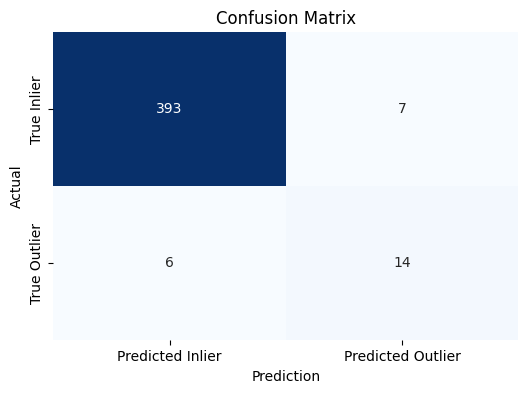

,precision,recall,f1-score,support
0,0.985,0.983,0.984,400
1,0.667,0.700,0.683,20
accuracy,0.969,0.969,0.969,1
macro avg,0.826,0.841,0.833,420
weighted avg,0.970,0.969,0.969,420


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
# Memuat perpustakaan
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Hasilkan data berkerumun dengan noise sintetis
X_clustered, _ = make_blobs(n_samples=400, centers=[[0, 0], [5, 5]], cluster_std=[0.5, 1.5], random_state=2024)
X_noise = np.random.uniform(low=-6, high=10, size=(20, 2))
X_combined = np.vstack([X_clustered, X_noise])
y_combined = np.array([0] * 400 + [1] * 20)

# Skalakan datanya
X_scaled = scaler.fit_transform(X_combined)

# Terapkan Faktor Pencilan (Outlier) Lokal
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_scaled)
y_pred_binary = np.where(y_pred == 1, 0, 1)

# Evaluasi prediksinya
print("\nExercise 2 Results:")
cm = confusion_matrix(y_combined, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Inlier', 'Predicted Outlier'],
            yticklabels=['True Inlier', 'True Outlier'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_combined, y_pred_binary, output_dict=True)
report = pd.DataFrame(report).transpose()
styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)

### Latihan 3: SVM Satu Kelas untuk Data Sensor Manufaktur
Latihan ini mendemonstrasikan deteksi kebaruan dalam simulasi lingkungan manufaktur. Anda akan melatih model hanya pada data operasional normal, lalu menggunakannya untuk mendeteksi observasi baru dari campuran data uji normal dan abnormal. Terakhir, Anda akan memvisualisasikan inlier dan mendeteksi hal baru dalam ruang fitur 2D.

### Langkah Penerapan:

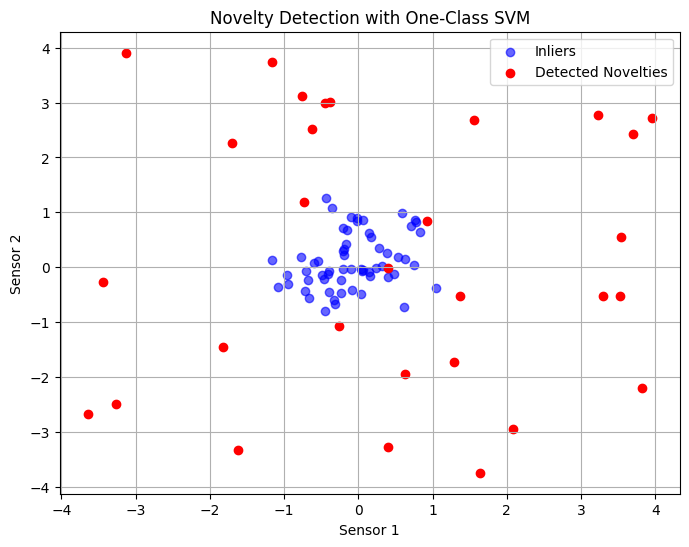

In [17]:
# Memuat perpustakaan
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Menghasilkan data normal dan baru
X_normal = np.random.normal(loc=0.0, scale=0.5, size=(300, 2))
X_novelty = np.random.uniform(low=-4, high=4, size=(30, 2))
X_train, X_test = train_test_split(X_normal, test_size=0.2, random_state=2024)
X_eval = np.vstack([X_test, X_novelty])

# Pasang SVM Satu Kelas pada data normal
svm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm_model.fit(X_train)
y_pred = svm_model.predict(X_eval)

# Visualisasikan prediksi
plt.figure(figsize=(8, 6))
plt.scatter(X_eval[y_pred == 1][:, 0], X_eval[y_pred == 1][:, 1], color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_eval[y_pred == -1][:, 0], X_eval[y_pred == -1][:, 1], color='red', label='Detected Novelties')
plt.title("Novelty Detection with One-Class SVM")
plt.xlabel("Sensor 1")
plt.ylabel("Sensor 2")
plt.legend()
plt.grid(True)
plt.show()

### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita telah mempelajari teknik identifikasi anomali:
* **Outlier Detection vs Novelty Detection:** Outlier detection mendeteksi anomali dalam data latih saat ini, sedangkan novelty detection mencari anomali pada data baru dengan asumsi data latih bersih dari anomali.
* **Isolation Forest:** Algoritma berbasis pohon acak yang mengisolasi anomali secara efisien karena letak data anomali yang biasanya dekat dengan akar pohon keputusan acak.
* **Local Outlier Factor (LOF):** Mengidentifikasi anomali berdasarkan perbedaan kepadatan lokal suatu sampel terhadap tetangga terdekatnya.
* **One-Class SVM:** Menentukan batas keputusan melingkari kelas mayoritas untuk menyaring data baru yang berada di luar batas tersebut.

#### 2. Pandangan ke Depan
Deteksi anomali sangat penting dalam sistem keamanan, deteksi penipuan keuangan, dan monitoring kesehatan mesin industri. Di **Bab 12**, kita akan melangkah mundur sejenak untuk mempelajari teknik evaluasi model secara komprehensif, guna memastikan model prediktif kita stabil dan terhindar dari bias yang menyesatkan sebelum dideploy.